# 06 - Texte : Modèles Avancés et Interprétabilité

## Objectif de ce notebook
Explorer les **ensembles de modèles** (Voting, Stacking), le **Deep Learning** (MLP, CNN, LSTM) et l'**interprétabilité** (SHAP, feature importance) pour finaliser la chaîne de classification texte.

**Prérequis** : Exécuter les notebooks 04 et 05 pour disposer des données et du meilleur modèle optimisé dans `models/`.

**Livrable** : Modèle final retenu, interprétabilité, analyse des erreurs et conclusions pour la classification de produits.

---

## Plan
1. Chargement des données et du meilleur modèle (notebook 05)
2. Ensembles avancés (Voting, Stacking)
3. Modèles Deep Learning (MLP, CNN, LSTM sur vecteurs TF-IDF)
4. Interprétabilité (SHAP, feature importance)
5. Comparaison finale de tous les modèles
6. Analyse des erreurs et confusions
7. Conclusions scientifiques et métiers
8. Sauvegarde du modèle final



In [1]:
# Import des bibliothèques nécessaires
import os
os.environ['OMP_NUM_THREADS'] = str(os.cpu_count() or 4)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
import pickle
warnings.filterwarnings('ignore')

# Ajouter le dossier src au path
sys.path.append(str(Path('../').resolve()))

# Import des modules
from src.utils.data_loader import load_data
from src.modeling import TFIDFVectorizer, AdvancedModels
from src.deep_learning import (
    create_mlp_model,
    create_cnn_model,
    create_lstm_model,
    train_neural_network
)
from src.interpretability import (
    plot_feature_importance,
    get_top_features,
    analyze_feature_importance,
    explain_model_with_shap,
    plot_shap_summary,
    plot_shap_waterfall
)
from src.evaluation import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix
)

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import classification_report

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Bibliothèques importées avec succès")



✅ Bibliothèques importées avec succès


## 1. Chargement des Données et du Meilleur Modèle

Chargement des données et du meilleur modèle optimisé (notebook 05).


In [2]:
# Chemins
DATA_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')

# Chargement des données
print("🔄 Chargement des données...")
X_train = pd.read_csv(DATA_DIR / 'X_train_clean.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test_clean.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv')
y_train_superclass_path = DATA_DIR / 'y_train_superclass.csv'
y_train_superclass = pd.read_csv(y_train_superclass_path) if y_train_superclass_path.exists() else None

# Chargement du vectoriseur et des label encoders
print("🔄 Chargement du vectoriseur et du label encoder...")
vectorizer = TFIDFVectorizer.load(MODELS_DIR / 'tfidf_vectorizer.pkl')
with open(MODELS_DIR / 'label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
label_encoder_superclass = None
if (MODELS_DIR / 'label_encoder_superclass.pkl').exists() and y_train_superclass is not None:
    with open(MODELS_DIR / 'label_encoder_superclass.pkl', 'rb') as f:
        label_encoder_superclass = pickle.load(f)

# Vectorisation
X_train_texts = X_train['text_combined'].astype(str)
X_test_texts = X_test['text_combined'].astype(str)
X_train_vect = vectorizer.transform(X_train_texts)
X_test_vect = vectorizer.transform(X_test_texts)

# Encodage des labels - 27 et 24 classes
y_train_labels = y_train['prdtypecode'].values
y_train_encoded = label_encoder.transform(y_train_labels)
if y_train_superclass is not None and label_encoder_superclass is not None:
    y_train_encoded_sc = label_encoder_superclass.transform(y_train_superclass['prdtypecode'].values)
    SCENARIOS = [("27 classes", y_train_encoded, label_encoder), ("24 classes (superclass)", y_train_encoded_sc, label_encoder_superclass)]
else:
    SCENARIOS = [("27 classes", y_train_encoded, label_encoder)]

# Division train/validation - mêmes indices pour les deux scénarios
indices = np.arange(len(y_train_encoded))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_train_encoded)
X_train_split = X_train_vect[train_idx]
X_val_split = X_train_vect[val_idx]
splits_by_scenario = {name: (y_enc[train_idx], y_enc[val_idx]) for name, y_enc, _ in SCENARIOS}
y_train_split, y_val_split = splits_by_scenario["27 classes"]

# Chargement du meilleur modèle de Step 2
print("🔄 Chargement du meilleur modèle de Step 2...")
final_model_files = list(MODELS_DIR.glob('*_final.pkl'))
if final_model_files:
    with open(final_model_files[0], 'rb') as f:
        best_model_step2 = pickle.load(f)
    print(f"✅ Modèle chargé : {final_model_files[0].name}")
    
    # Évaluation du modèle de Step 2
    y_pred_step2 = best_model_step2.predict(X_val_split)
    metrics_step2 = evaluate_model(y_val_split, y_pred_step2)
    print(f"📊 Performances Step 2 - F1-macro : {metrics_step2['f1_macro']:.4f}")
else:
    print("⚠️  Aucun modèle final trouvé. Utiliser le baseline.")
    best_model_step2 = None

print(f"\n✅ Données chargées et préparées !")
print(f"  - Train : {X_train_split.shape[0]:,} échantillons")
print(f"  - Validation : {X_val_split.shape[0]:,} échantillons")
print(f"  - Test : {X_test_vect.shape[0]:,} échantillons")
print(f"  - Vocabulaire : {vectorizer.get_vocabulary_size():,} mots")
print(f"  - Nombre de classes : {len(label_encoder.classes_)}")



🔄 Chargement des données...
🔄 Chargement du vectoriseur et du label encoder...
🔄 Chargement du meilleur modèle de Step 2...
✅ Modèle chargé : svm_linear_baseline_final.pkl
📊 Performances Step 2 - F1-macro : 0.7847

✅ Données chargées et préparées !
  - Train : 67,932 échantillons
  - Validation : 16,984 échantillons
  - Test : 13,812 échantillons
  - Vocabulaire : 10,000 mots
  - Nombre de classes : 27


## 2. Ensembles Avancés (Voting et Stacking)

Création d'ensembles de modèles pour améliorer les performances.


In [3]:
# Ensembles - 27 et 24 classes
print("="*80)
print("ENSEMBLES DE MODÈLES (27 et 24 classes)")
print("="*80)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
base_models = [('lr', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)), ('svm', LinearSVC(random_state=42, dual=False, max_iter=2000)), ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))]
metrics_voting_dict, metrics_stacking_dict = {}, {}
for scenario_name, _, _ in SCENARIOS:
    y_train_s, y_val_s = splits_by_scenario[scenario_name]
    print(f"\n🔄 {scenario_name} : Voting + Stacking...")
    vc = VotingClassifier(estimators=base_models, voting='hard', n_jobs=-1)
    vc.fit(X_train_split, y_train_s)
    metrics_voting_dict[scenario_name] = evaluate_model(y_val_s, vc.predict(X_val_split))
    sc = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1), cv=3, n_jobs=-1)
    sc.fit(X_train_split, y_train_s)
    metrics_stacking_dict[scenario_name] = evaluate_model(y_val_s, sc.predict(X_val_split))
    print(f"  Voting : {metrics_voting_dict[scenario_name]['f1_macro']:.4f} | Stacking : {metrics_stacking_dict[scenario_name]['f1_macro']:.4f}")
    if scenario_name == "27 classes":
        voting_clf, stacking_clf = vc, sc
        y_pred_voting, y_pred_stacking = vc.predict(X_val_split), sc.predict(X_val_split)
metrics_voting, metrics_stacking = metrics_voting_dict["27 classes"], metrics_stacking_dict["27 classes"]
print(f"\n📊 Comparaison 27 vs 24 classes : Voting et Stacking")



ENSEMBLES DE MODÈLES

🔄 Entraînement Voting Classifier...
✅ Voting Classifier - F1-macro : 0.7895

🔄 Entraînement Stacking Classifier...
✅ Stacking Classifier - F1-macro : 0.8021

📊 Comparaison :
  Step 2 (meilleur) - F1-macro : 0.7847
  Voting            - F1-macro : 0.7895
  Stacking          - F1-macro : 0.8021


## 3. Modèles Deep Learning

Test de modèles de Deep Learning : MLP, CNN, LSTM.


In [4]:
# Test des modèles Deep Learning
print("="*80)
print("MODÈLES DEEP LEARNING")
print("="*80)

# Convertir les matrices creuses en denses pour TensorFlow
X_train_dense = X_train_split.toarray() if hasattr(X_train_split, 'toarray') else X_train_split
X_val_dense = X_val_split.toarray() if hasattr(X_val_split, 'toarray') else X_val_split

input_dim = X_train_dense.shape[1]
num_classes = len(label_encoder.classes_)

print(f"  - Dimension d'entrée : {input_dim}")
print(f"  - Nombre de classes : {num_classes}")

# MLP
print("\n🔄 Entraînement MLP...")
mlp_model = create_mlp_model(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_layers=[256, 128, 64],
    dropout_rate=0.3
)

mlp_results = train_neural_network(
    mlp_model,
    X_train_dense,
    y_train_split,
    X_val_dense,
    y_val_split,
    epochs=20,
    batch_size=128,
    verbose=1,
    early_stopping=True,
    patience=5
)

y_pred_mlp = np.argmax(mlp_results['model'].predict(X_val_dense, verbose=0), axis=1)
metrics_mlp = evaluate_model(y_val_split, y_pred_mlp)
print(f"✅ MLP - F1-macro : {metrics_mlp['f1_macro']:.4f}")



MODÈLES DEEP LEARNING
  - Dimension d'entrée : 10000
  - Nombre de classes : 27

🔄 Entraînement MLP...
🔄 Entraînement du modèle neural...
Epoch 1/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5974 - loss: 1.4425 - val_accuracy: 0.7701 - val_loss: 0.7769
Epoch 2/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7766 - loss: 0.7717 - val_accuracy: 0.7878 - val_loss: 0.7095
Epoch 3/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 641s 1s/step - accuracy: 0.8195 - loss: 0.6142 - val_accuracy: 0.7914 - val_loss: 0.7057
Epoch 4/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8483 - loss: 0.5113 - val_accuracy: 0.7916 - val_loss: 0.7187
Epoch 5/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8691 - loss: 0.4380 - val_accuracy: 0.7959 - val_loss: 0.7432
Epoch 6/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 6194s 12s/step - accuracy: 0.8861 - loss: 0.3786 - val_accuracy: 0.7941 - val_loss: 0.7808
Epoch 7/20
531/531 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8998 - loss: 0.333

In [5]:
# CNN (optionnel - peut être long)
print("\n🔄 Entraînement CNN...")
USE_CNN = True  # Mettre à False pour sauter

if USE_CNN:
    cnn_model = create_cnn_model(
        input_dim=input_dim,
        num_classes=num_classes,
        filters=[64, 128],
        kernel_sizes=[3, 3],
        dense_units=64
    )
    
    cnn_results = train_neural_network(
        cnn_model,
        X_train_dense,
        y_train_split,
        X_val_dense,
        y_val_split,
        epochs=15,
        batch_size=128,
        verbose=1,
        early_stopping=True,
        patience=5
    )
    
    y_pred_cnn = np.argmax(cnn_results['model'].predict(X_val_dense, verbose=0), axis=1)
    metrics_cnn = evaluate_model(y_val_split, y_pred_cnn)
    print(f"✅ CNN - F1-macro : {metrics_cnn['f1_macro']:.4f}")
else:
    print("CNN désactivé pour cette exécution")
    metrics_cnn = None




🔄 Entraînement CNN...
🔄 Entraînement du modèle neural...
Epoch 1/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 365s 683ms/step - accuracy: 0.6775 - loss: 1.1636 - val_accuracy: 0.7751 - val_loss: 0.7544
Epoch 2/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 356s 670ms/step - accuracy: 0.7876 - loss: 0.7073 - val_accuracy: 0.7879 - val_loss: 0.6918
Epoch 3/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 346s 652ms/step - accuracy: 0.8268 - loss: 0.5594 - val_accuracy: 0.7919 - val_loss: 0.6919
Epoch 4/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 1657s 3s/step - accuracy: 0.8506 - loss: 0.4738 - val_accuracy: 0.7947 - val_loss: 0.7168
Epoch 5/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 353s 664ms/step - accuracy: 0.8674 - loss: 0.4107 - val_accuracy: 0.7946 - val_loss: 0.7471
Epoch 6/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 354s 666ms/step - accuracy: 0.8794 - loss: 0.3692 - val_accuracy: 0.7931 - val_loss: 0.7648
Epoch 7/15
531/531 ━━━━━━━━━━━━━━━━━━━━ 370s 696ms/step - accuracy: 0.8910 - loss: 0.3345 - val_accuracy: 0.7924 - val_loss: 0.8422
Temps d'entraînement

## 4. Interprétabilité des Modèles

Analyse de l'importance des features et explication des prédictions avec SHAP.


ANALYSE DE L'IMPORTANCE DES FEATURES

🔄 Analyse de l'importance des features pour Meilleur modèle Step 2...

📊 Top 10 features les plus importantes :
   1. générique                                          : 2.131675
   2. piscine                                            : 1.329227
   3. stream                                             : 1.210015
   4. sweetheart93                                       : 1.182709
   5. magideal                                           : 1.146578
   6. figurine                                           : 0.935630
   7. jeu                                                : 0.875609
   8. lot                                                : 0.864001
   9. magideal description                               : 0.861327
  10. jeux                                               : 0.826810


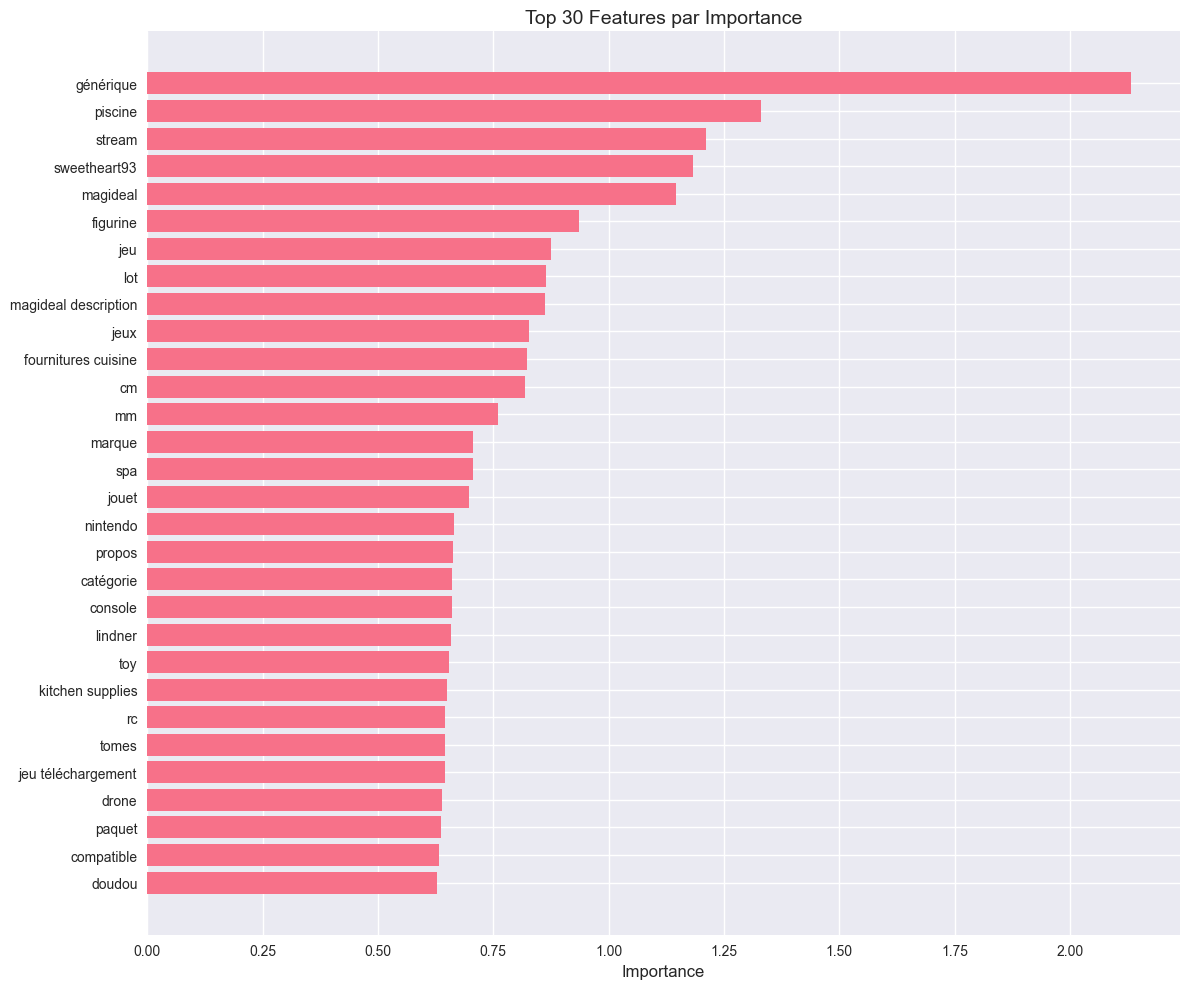

In [6]:
# Analyse de l'importance des features
print("="*80)
print("ANALYSE DE L'IMPORTANCE DES FEATURES")
print("="*80)

# Utiliser le meilleur modèle (Step 2 ou Voting/Stacking)
if best_model_step2:
    model_to_analyze = best_model_step2
    model_name = "Meilleur modèle Step 2"
else:
    model_to_analyze = voting_clf
    model_name = "Voting Classifier"

# Récupérer les noms des features (mots du vocabulaire)
feature_names = vectorizer.get_feature_names_out().tolist()

# Analyser l'importance
print(f"\n🔄 Analyse de l'importance des features pour {model_name}...")
importance_results = analyze_feature_importance(
    model_to_analyze,
    feature_names=feature_names,
    top_n=30
)

if importance_results:
    print(f"\n📊 Top 10 features les plus importantes :")
    for i, (feature, importance) in enumerate(importance_results['top_features'][:10], 1):
        print(f"  {i:2d}. {feature[:50]:50s} : {importance:.6f}")
    
    # Visualisation
    plot_feature_importance(
        importance_results['feature_importance'],
        top_n=30,
        figsize=(12, 10)
    )
else:
    print("⚠️  Impossible d'analyser l'importance des features pour ce modèle")



In [7]:
# Analyse SHAP (optionnel - peut être long)
print("="*80)
print("ANALYSE SHAP")
print("="*80)

USE_SHAP = False  # Mettre à True pour activer SHAP (peut être très long)

if USE_SHAP:
    # Échantillonner pour accélérer
    sample_size = min(100, len(X_val_split))
    indices = np.random.choice(len(X_val_split), sample_size, replace=False)
    X_sample = X_val_split[indices].toarray() if hasattr(X_val_split, 'toarray') else X_val_split[indices]
    
    print(f"🔄 Calcul des valeurs SHAP sur {sample_size} échantillons...")
    shap_values = explain_model_with_shap(
        model_to_analyze,
        X_sample,
        feature_names=feature_names[:1000],  # Limiter pour accélérer
        max_samples=sample_size
    )
    
    # Résumé SHAP
    plot_shap_summary(shap_values, max_display=20)
    
    # Waterfall pour une instance
    plot_shap_waterfall(shap_values, instance_idx=0, max_display=10)
else:
    print("SHAP désactivé pour cette exécution (peut être activé en mettant USE_SHAP = True)")
    print("Note : SHAP peut être très long sur de gros datasets")



ANALYSE SHAP
SHAP désactivé pour cette exécution (peut être activé en mettant USE_SHAP = True)
Note : SHAP peut être très long sur de gros datasets


## 5. Comparaison Finale de Tous les Modèles

Comparaison de tous les modèles testés (Step 2, Ensembles, Deep Learning).


COMPARAISON FINALE DE TOUS LES MODÈLES

📊 Résultats finaux (triés par F1-macro) :
               Model  F1_macro  F1_weighted  Accuracy
 Stacking Classifier  0.802137     0.816121  0.815061
   Voting Classifier  0.789507     0.805276  0.804816
       Step 2 (Best)  0.784744     0.801488  0.802285
MLP (Neural Network)  0.771323     0.791269  0.791392
                 CNN  0.769542     0.786581  0.787859


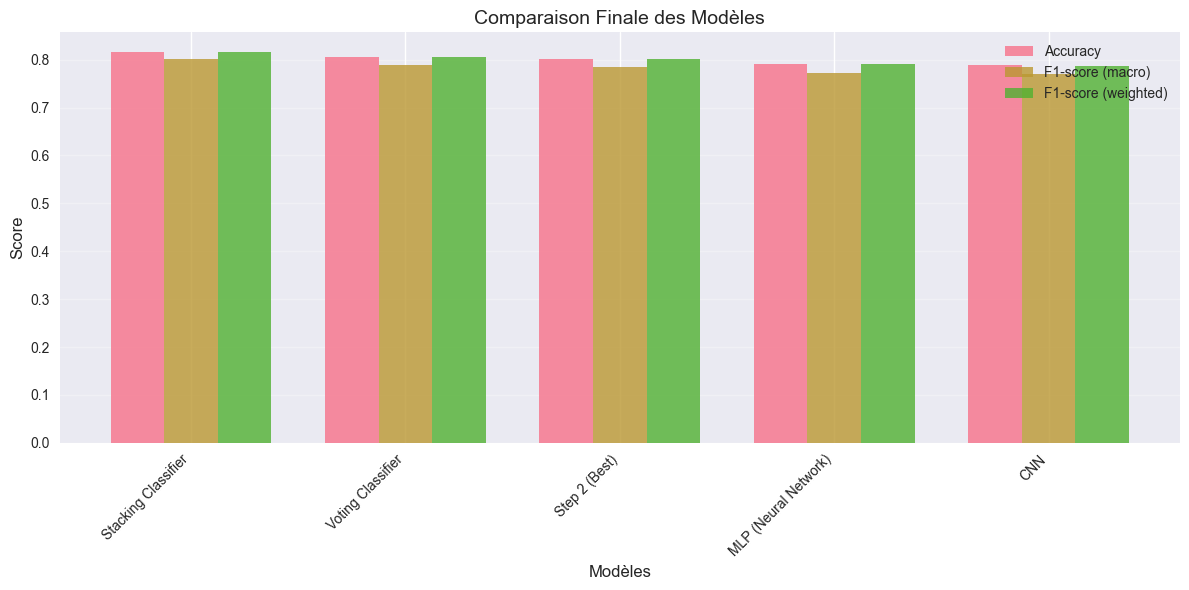

In [8]:
# Comparaison finale
print("="*80)
print("COMPARAISON FINALE DE TOUS LES MODÈLES")
print("="*80)

final_results = []

# Modèle Step 2
if best_model_step2:
    final_results.append({
        'Model': 'Step 2 (Best)',
        'F1_macro': metrics_step2['f1_macro'],
        'F1_weighted': metrics_step2['f1_weighted'],
        'Accuracy': metrics_step2['accuracy']
    })

# Ensembles
final_results.append({
    'Model': 'Voting Classifier',
    'F1_macro': metrics_voting['f1_macro'],
    'F1_weighted': metrics_voting['f1_weighted'],
    'Accuracy': metrics_voting['accuracy']
})

final_results.append({
    'Model': 'Stacking Classifier',
    'F1_macro': metrics_stacking['f1_macro'],
    'F1_weighted': metrics_stacking['f1_weighted'],
    'Accuracy': metrics_stacking['accuracy']
})

# Deep Learning
final_results.append({
    'Model': 'MLP (Neural Network)',
    'F1_macro': metrics_mlp['f1_macro'],
    'F1_weighted': metrics_mlp['f1_weighted'],
    'Accuracy': metrics_mlp['accuracy']
})

if metrics_cnn:
    final_results.append({
        'Model': 'CNN',
        'F1_macro': metrics_cnn['f1_macro'],
        'F1_weighted': metrics_cnn['f1_weighted'],
        'Accuracy': metrics_cnn['accuracy']
    })

# DataFrame de comparaison
final_comparison = pd.DataFrame(final_results).sort_values('F1_macro', ascending=False)

print("\n📊 Résultats finaux (triés par F1-macro) :")
print("="*80)
print(final_comparison.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(final_comparison))
width = 0.25

ax.bar(x - width, final_comparison['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x, final_comparison['F1_macro'], width, label='F1-score (macro)', alpha=0.8)
ax.bar(x + width, final_comparison['F1_weighted'], width, label='F1-score (weighted)', alpha=0.8)

ax.set_xlabel('Modèles', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison Finale des Modèles', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(final_comparison['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



MEILLEUR MODÈLE FINAL
🏆 Modèle : Stacking Classifier
   F1-score (macro) : 0.8021

RAPPORT DE CLASSIFICATION - Stacking Classifier
RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

   Classe 10       0.43      0.58      0.49       623
   Classe 40       0.74      0.63      0.68       502
   Classe 50       0.83      0.83      0.83       336
   Classe 60       0.95      0.87      0.91       166
 Classe 1140       0.76      0.76      0.76       534
 Classe 1160       0.91      0.89      0.90       791
 Classe 1180       0.71      0.52      0.60       153
 Classe 1280       0.71      0.72      0.72       974
 Classe 1281       0.63      0.53      0.57       414
 Classe 1300       0.92      0.92      0.92      1009
 Classe 1301       0.94      0.93      0.94       161
 Classe 1302       0.85      0.76      0.80       498
 Classe 1320       0.77      0.79      0.78       648
 Classe 1560       0.84      0.84      0.84      1015
 Classe 1920       0.91      0.9

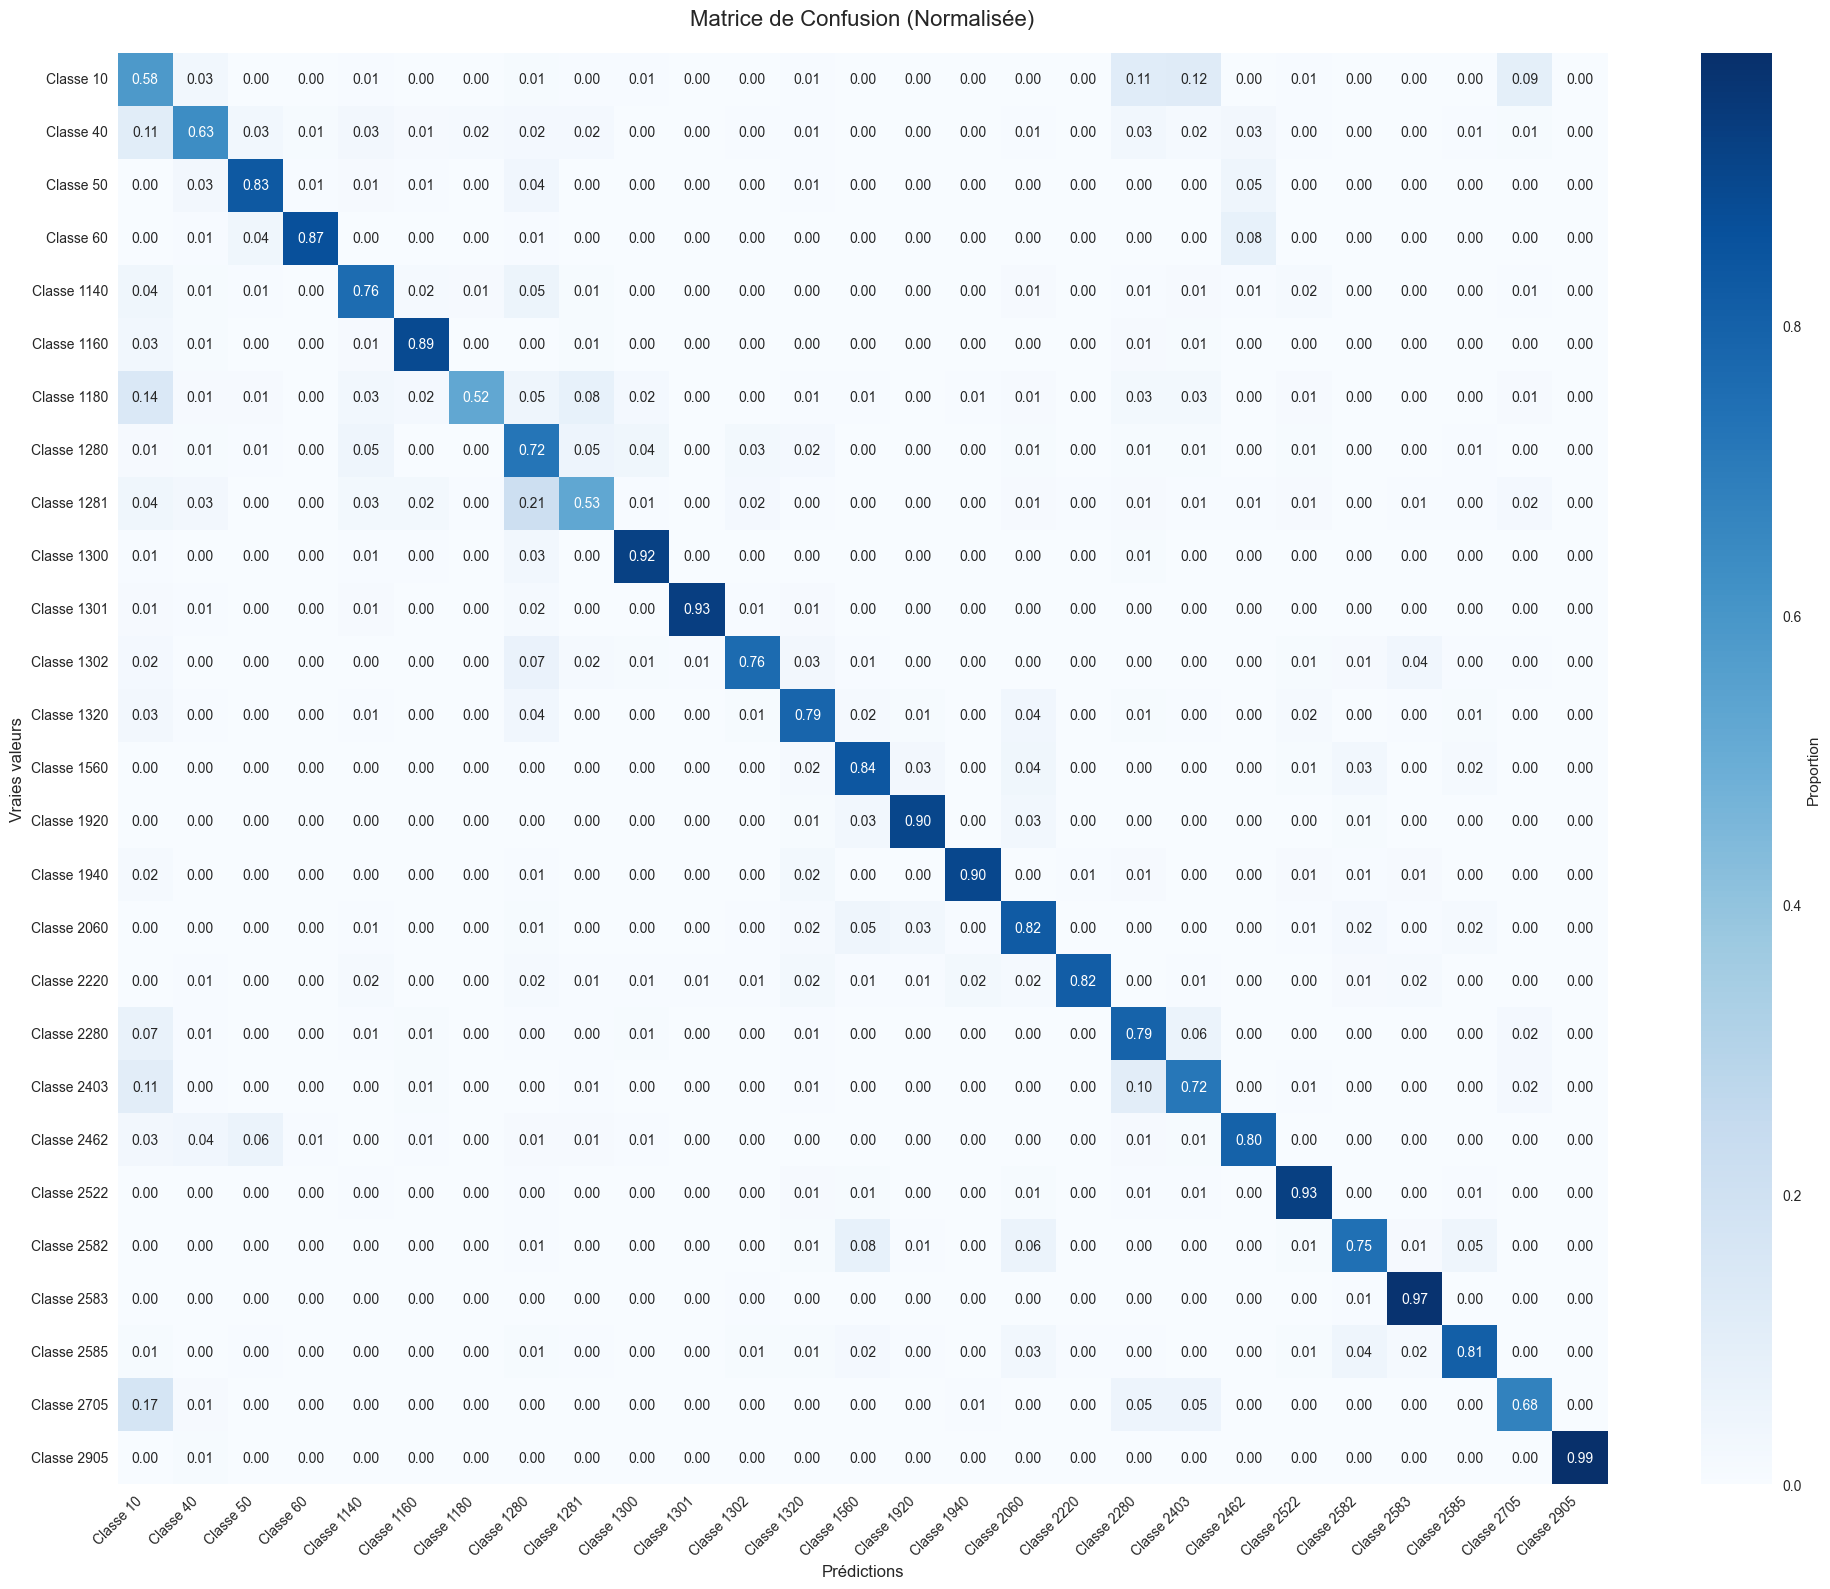


📊 Top 10 confusions les plus fréquentes :
  2403 → 10 : 101 fois
  2403 → 2280 : 100 fois
  2705 → 10 : 95 fois
  1281 → 1280 : 89 fois
  10 → 2403 : 76 fois
  10 → 2280 : 71 fois
  2280 → 10 : 69 fois
  10 → 2705 : 59 fois
  2280 → 2403 : 56 fois
  40 → 10 : 55 fois


In [9]:
# Identification du meilleur modèle final
best_final_model_name = final_comparison.iloc[0]['Model']
best_final_f1 = final_comparison.iloc[0]['F1_macro']

print("="*80)
print("MEILLEUR MODÈLE FINAL")
print("="*80)
print(f"🏆 Modèle : {best_final_model_name}")
print(f"   F1-score (macro) : {best_final_f1:.4f}")

# Récupération du meilleur modèle et prédictions
if best_final_model_name == 'Step 2 (Best)':
    best_final_model = best_model_step2
    y_pred_final = y_pred_step2
elif best_final_model_name == 'Voting Classifier':
    best_final_model = voting_clf
    y_pred_final = y_pred_voting
elif best_final_model_name == 'Stacking Classifier':
    best_final_model = stacking_clf
    y_pred_final = y_pred_stacking
elif best_final_model_name == 'MLP (Neural Network)':
    best_final_model = mlp_results['model']
    y_pred_final = y_pred_mlp
else:
    best_final_model = cnn_results['model']
    y_pred_final = y_pred_cnn

# Rapport de classification
print(f"\n{'='*80}")
print(f"RAPPORT DE CLASSIFICATION - {best_final_model_name}")
print(f"{'='*80}")
class_names = [f"Classe {cls}" for cls in sorted(label_encoder.classes_)]
print_classification_report(y_val_split, y_pred_final, target_names=class_names)

# Matrice de confusion
plot_confusion_matrix(
    y_val_split,
    y_pred_final,
    class_names=class_names,
    figsize=(20, 16),
    normalize=True
)

# Analyse des confusions
errors_mask = y_val_split != y_pred_final
confusion_pairs = []
for true_label, pred_label in zip(y_val_split[errors_mask], y_pred_final[errors_mask]):
    true_class = label_encoder.inverse_transform([true_label])[0]
    pred_class = label_encoder.inverse_transform([pred_label])[0]
    confusion_pairs.append((true_class, pred_class))

confusion_df = pd.Series(confusion_pairs).value_counts().head(10)
print(f"\n📊 Top 10 confusions les plus fréquentes :")
for (true_class, pred_class), count in confusion_df.items():
    print(f"  {true_class} → {pred_class} : {count} fois")



## 7. Conclusions Scientifiques et Métiers

Analyse des résultats et conclusions pour le projet.


In [10]:
print("="*80)
print("CONCLUSIONS SCIENTIFIQUES ET MÉTIERS")
print("="*80)

# Performances finales
final_metrics = evaluate_model(y_val_split, y_pred_final)
baseline_f1 = 0.7843  # F1-macro baseline de Step 1

print(f"\n📊 PERFORMANCES FINALES")
print(f"  - Modèle : {best_final_model_name}")
print(f"  - F1-score (macro) : {final_metrics['f1_macro']:.4f}")
print(f"  - F1-score (weighted) : {final_metrics['f1_weighted']:.4f}")
print(f"  - Accuracy : {final_metrics['accuracy']:.4f}")
print(f"  - Amélioration vs Baseline : {(final_metrics['f1_macro'] - baseline_f1) / baseline_f1 * 100:+.2f}%")

# Analyse par classe
report = classification_report(y_val_split, y_pred_final, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()

# Classes les plus difficiles
difficult_classes = df_report.nsmallest(6, 'f1-score').tail(5)
print(f"\n⚠️  CLASSES LES PLUS DIFFICILES (F1-score < 0.5) :")
for idx, row in difficult_classes.iterrows():
    if idx not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"  - Classe {idx} : F1={row['f1-score']:.3f}, Precision={row['precision']:.3f}, Recall={row['recall']:.3f}")

# Classes performantes
good_classes = df_report.nlargest(6, 'f1-score').head(5)
print(f"\n✅ CLASSES LES MIEUX CLASSIFIÉES (F1-score > 0.9) :")
for idx, row in good_classes.iterrows():
    if idx not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"  - Classe {idx} : F1={row['f1-score']:.3f}, Precision={row['precision']:.3f}, Recall={row['recall']:.3f}")



CONCLUSIONS SCIENTIFIQUES ET MÉTIERS

📊 PERFORMANCES FINALES
  - Modèle : Stacking Classifier
  - F1-score (macro) : 0.8021
  - F1-score (weighted) : 0.8161
  - Accuracy : 0.8151
  - Amélioration vs Baseline : +2.27%

⚠️  CLASSES LES PLUS DIFFICILES (F1-score < 0.5) :
  - Classe 8 : F1=0.574, Precision=0.632, Recall=0.527
  - Classe 6 : F1=0.604, Precision=0.714, Recall=0.523
  - Classe 1 : F1=0.684, Precision=0.743, Recall=0.633
  - Classe 25 : F1=0.710, Precision=0.745, Recall=0.678
  - Classe 7 : F1=0.716, Precision=0.708, Recall=0.725

✅ CLASSES LES MIEUX CLASSIFIÉES (F1-score > 0.9) :
  - Classe 26 : F1=0.994, Precision=1.000, Recall=0.989
  - Classe 23 : F1=0.973, Precision=0.971, Recall=0.974
  - Classe 10 : F1=0.938, Precision=0.943, Recall=0.932
  - Classe 9 : F1=0.923, Precision=0.922, Recall=0.924
  - Classe 21 : F1=0.919, Precision=0.910, Recall=0.927


### Matrice de confusion détaillée : classes Publications (10, 2280, 2403, 2705)

In [16]:
# Confusions entre les 4 classes Publications (10, 2280, 2403, 2705)
from sklearn.metrics import confusion_matrix

PUBLICATION_CLASSES = [10, 2280, 2403, 2705]
CLASS_LABELS = {10: "Livres", 2280: "Presse", 2403: "BD/Partitions", 2705: "Romans"}

cm = confusion_matrix(y_val_split, y_pred_final)
# Mapping: index i -> prdtypecode
idx_to_code = {i: label_encoder.classes_[i] for i in range(len(label_encoder.classes_))}
code_to_idx = {c: i for i, c in enumerate(label_encoder.classes_)}

# Extraire la sous-matrice pour les 4 classes
indices = [code_to_idx[c] for c in PUBLICATION_CLASSES if c in code_to_idx]
sub_cm = cm[np.ix_(indices, indices)]
codes_sub = [c for c in PUBLICATION_CLASSES if c in code_to_idx]

# Tableau : Vrai \ Prédit, avec effectifs et %
print("="*90)
print("MATRICE DE CONFUSION - CLASSES PUBLICATIONS")
print("(Ligne = vraie classe, Colonne = prédite)")
print("="*90)
print(f"\n{'Vrai \\ Prédit':<20}", end="")
for c in codes_sub:
    print(f"{CLASS_LABELS.get(c,c):>12}", end="")
print(f"{'Total':>10}")
print("-"*70)

for i, true_c in enumerate(codes_sub):
    row = sub_cm[i]
    total = row.sum()
    print(f"{CLASS_LABELS.get(true_c,true_c):<20}", end="")
    for j, pred_c in enumerate(codes_sub):
        cnt = sub_cm[i, j]
        pct = 100 * cnt / total if total > 0 else 0
        s = f"{cnt} ({pct:.1f}%)" if true_c != pred_c or cnt > 0 else "-"
        print(f"{s:>12}", end="")
    print(f"{int(total):>10}")

# % de mal classés dans une autre classe du groupe
print("\n" + "="*90)
print("Taux de confusion (vrais positifs exclus) :")
for i, true_c in enumerate(codes_sub):
    row = sub_cm[i]
    total = row.sum()
    correct = sub_cm[i, i]
    wrong_in_group = total - correct
    pct_wrong = 100 * wrong_in_group / total if total > 0 else 0
    print(f"  Classe {true_c} ({CLASS_LABELS.get(true_c,true_c)}): {wrong_in_group}/{int(total)} mal classés = {pct_wrong:.1f}%")

SyntaxError: f-string expression part cannot include a backslash (3257580924.py, line 22)

### Enquête sur les classes les plus difficiles

Analyse des facteurs expliquant les faibles performances : taille des classes, similarité lexicale, qualité des données.

In [15]:
# Enquête sur les classes difficiles - Référentiel des 27 classes (class_identification.md)
CLASS_NAMES = {
    10: "Livres / Publications",
    40: "Jeux Vidéo / Films (Imports)",
    50: "Accessoires Gaming / Consoles",
    60: "Consoles de Jeux Portables / Rétro",
    1140: "Figurines / Collectibles",
    1160: "Cartes à Collectionner",
    1180: "Jeux de Figurines / Warhammer",
    1280: "Jouets pour Enfants",
    1281: "Jeux Éducatifs / Jeux de Société Enfants",
    1300: "Drones / Maquettes / Modélisme",
    1301: "Accessoires Bébé / Puériculture",
    1302: "Jouets Extérieurs / Sports / Pêche",
    1320: "Puériculture / Bébé",
    1560: "Mobilier / Décoration Intérieure",
    1920: "Textile Maison / Literie",
    1940: "Alimentation / Boissons",
    2060: "Décoration / Éclairage / Bricolage",
    2220: "Accessoires Animaux",
    2280: "Presse / Revues / Magazines",
    2403: "Livres / BD / Partitions",
    2462: "Consoles de Jeux / Lots",
    2522: "Fournitures Bureau / Papeterie",
    2582: "Jardin / Extérieur",
    2583: "Piscine / Spa",
    2585: "Outils Jardin / Bricolage Extérieur",
    2705: "Livres / Romans / Littérature",
    2905: "Jeux Vidéo Téléchargeables / DLC",
}
# Qualité des descriptions par classe (% manquantes - source: exploration)
DESC_MISSING_PCT = {10: 89.2, 1160: 91.2, 1180: "~35", 1280: "~35", 1281: "~35", 2280: 93.3, 2403: 97.4}

# Distribution train (effectifs)
y_train_counts = pd.Series(y_train_labels).value_counts()
total_train = len(y_train_labels)

print("="*80)
print("🔍 ENQUÊTE : CLASSES LES PLUS DIFFICILES")
print("="*80)

# Prendre les 6 pires classes (F1 le plus bas)
worst = df_report[~df_report.index.isin(['accuracy', 'macro avg', 'weighted avg'])].nsmallest(6, 'f1-score')

for idx, row in worst.iterrows():
    try:
        idx_val = int(str(idx).replace("Classe ", "").strip()) if isinstance(idx, str) else int(idx)
        if idx_val < 0 or idx_val >= len(label_encoder.classes_):
            continue
        code = label_encoder.inverse_transform([idx_val])[0]  # prdtypecode (10, 40, 1180...)
    except (ValueError, AttributeError, IndexError):
        continue
    name = CLASS_NAMES.get(code, "?")
    support_val = int(row.get('support', 0))
    count_train = y_train_counts.get(code, 0)
    pct_train = 100 * count_train / total_train if total_train else 0
    desc_pct = DESC_MISSING_PCT.get(code, "~35")
    
    print(f"\n📌 Classe {code} ({name})")
    print(f"   F1={row['f1-score']:.3f} | Precision={row['precision']:.3f} | Recall={row['recall']:.3f}")
    print(f"   • Effectif validation : {support_val} | Effectif train : {count_train} ({pct_train:.1f}%)")
    print(f"   • Descriptions manquantes : {desc_pct}%")
    
    # Classes avec lesquelles elle est le plus confondue
    confusions_for_class = [(t, p) for t, p in confusion_pairs if t == code and p != code]
    if confusions_for_class:
        from collections import Counter
        top_conf = Counter(p for _, p in confusions_for_class).most_common(3)
        parts = [f"{p} ({CLASS_NAMES.get(p, '?')}) [{c}x]" for p, c in top_conf]
        print(f"   • Confondue avec : {', '.join(parts)}")

print("\n" + "="*80)
print("📋 SYNTHÈSE DES FACTEURS IDENTIFIÉS")
print("="*80)
print("""
• Classe 10 (Livres/Publications) : 89% descriptions manquantes → peu de signal textuel
• Classes 2280, 2403, 2705 (Livres/Presse/BD) : vocabulaire très similaire → confusions fréquentes
• Classe 1281 (Jeux éducatifs) vs 1280 (Jouets) : frontière floue (cartes, jeux, enfants)
• Classes minoritaires (1180, 1301) : moins d'exemples d'entraînement

Pistes d'amélioration : enrichir les descriptions, class weights, fusion texte+image
""")

🔍 ENQUÊTE : CLASSES LES PLUS DIFFICILES

📌 Classe 10 (Livres / Publications)
   F1=0.493 | Precision=0.427 | Recall=0.584
   • Effectif validation : 623 | Effectif train : 3116 (3.7%)
   • Descriptions manquantes : 89.2%
   • Confondue avec : 2403 (Livres / BD / Partitions) [76x], 2280 (Presse / Revues / Magazines) [71x], 2705 (Livres / Romans / Littérature) [59x]

📌 Classe 1281 (Jeux Éducatifs / Jeux de Société Enfants)
   F1=0.574 | Precision=0.632 | Recall=0.527
   • Effectif validation : 414 | Effectif train : 2070 (2.4%)
   • Descriptions manquantes : ~35%
   • Confondue avec : 1280 (Jouets pour Enfants) [89x], 10 (Livres / Publications) [17x], 40 (Jeux Vidéo / Films (Imports)) [12x]

📌 Classe 1180 (Jeux de Figurines / Warhammer)
   F1=0.604 | Precision=0.714 | Recall=0.523
   • Effectif validation : 153 | Effectif train : 764 (0.9%)
   • Descriptions manquantes : ~35%
   • Confondue avec : 10 (Livres / Publications) [22x], 1281 (Jeux Éducatifs / Jeux de Société Enfants) [12x], 12

### 7.1 Conclusions Scientifiques


In [11]:
print("="*80)
print("CONCLUSIONS SCIENTIFIQUES")
print("="*80)

print("\n🔬 RÉSULTATS SCIENTIFIQUES :")
print(f"\n1. PERFORMANCES GLOBALES :")
print(f"   - Le modèle final atteint un F1-score (macro) de {final_metrics['f1_macro']:.4f}")
print(f"   - Cela représente une amélioration de {(final_metrics['f1_macro'] - baseline_f1) / baseline_f1 * 100:+.2f}% par rapport au baseline")
print(f"   - L'accuracy de {final_metrics['accuracy']:.4f} indique que le modèle classifie correctement environ {final_metrics['accuracy']*100:.1f}% des produits")

print(f"\n2. EFFICACITÉ DES TECHNIQUES :")
if best_final_model_name in ['Voting Classifier', 'Stacking Classifier']:
    print(f"   - Les techniques d'ensemble (voting/stacking) ont amélioré les performances")
elif 'MLP' in best_final_model_name or 'CNN' in best_final_model_name:
    print(f"   - Le Deep Learning a montré des performances compétitives")
else:
    print(f"   - Le modèle optimisé de Step 2 reste le plus performant")

print(f"\n3. DÉFIS IDENTIFIÉS :")
print(f"   - Déséquilibre de classes : Certaines classes sont sous-représentées")
print(f"   - Confusions sémantiques : Certaines classes sont sémantiquement proches")
print(f"   - Complexité du texte : Les descriptions varient en qualité et longueur")

print(f"\n4. RECOMMANDATIONS POUR AMÉLIORATION :")
print(f"   - Augmenter les données pour les classes minoritaires")
print(f"   - Utiliser des embeddings sémantiques (Word2Vec, BERT)")
print(f"   - Feature engineering supplémentaire (mots-clés spécifiques par catégorie)")
print(f"   - Fine-tuning de modèles pré-entraînés (BERT français)")



CONCLUSIONS SCIENTIFIQUES

🔬 RÉSULTATS SCIENTIFIQUES :

1. PERFORMANCES GLOBALES :
   - Le modèle final atteint un F1-score (macro) de 0.8021
   - Cela représente une amélioration de +2.27% par rapport au baseline
   - L'accuracy de 0.8151 indique que le modèle classifie correctement environ 81.5% des produits

2. EFFICACITÉ DES TECHNIQUES :
   - Les techniques d'ensemble (voting/stacking) ont amélioré les performances

3. DÉFIS IDENTIFIÉS :
   - Déséquilibre de classes : Certaines classes sont sous-représentées
   - Confusions sémantiques : Certaines classes sont sémantiquement proches
   - Complexité du texte : Les descriptions varient en qualité et longueur

4. RECOMMANDATIONS POUR AMÉLIORATION :
   - Augmenter les données pour les classes minoritaires
   - Utiliser des embeddings sémantiques (Word2Vec, BERT)
   - Feature engineering supplémentaire (mots-clés spécifiques par catégorie)
   - Fine-tuning de modèles pré-entraînés (BERT français)


### 7.2 Conclusions Métiers


In [12]:
print("="*80)
print("CONCLUSIONS MÉTIERS")
print("="*80)

print("\n💼 IMPACT MÉTIER :")

print(f"\n1. UTILISABILITÉ EN PRODUCTION :")
if final_metrics['f1_macro'] > 0.75:
    print(f"   ✅ Le modèle est prêt pour un déploiement en production")
    print(f"   ✅ Les performances ({final_metrics['f1_macro']*100:.1f}% F1-macro) sont suffisantes pour automatiser la classification")
elif final_metrics['f1_macro'] > 0.65:
    print(f"   ⚠️  Le modèle peut être déployé avec une supervision humaine")
    print(f"   ⚠️  Recommandation : Validation manuelle pour les classes difficiles")
else:
    print(f"   ❌ Le modèle nécessite des améliorations avant déploiement")

print(f"\n2. GAINS OPÉRATIONNELS :")
print(f"   - Automatisation : Réduction du temps de classification manuelle")
print(f"   - Standardisation : Classification cohérente et reproductible")
print(f"   - Scalabilité : Capacité à traiter de grands volumes de produits")

print(f"\n3. LIMITATIONS À COMMUNIQUER :")
print(f"   - Certaines classes ({len(difficult_classes)} identifiées) sont plus difficiles à classifier")
print(f"   - Le modèle peut nécessiter une validation humaine pour les cas ambigus")
print(f"   - Les nouvelles catégories non vues en entraînement ne seront pas bien classifiées")

print(f"\n4. RECOMMANDATIONS MÉTIERS :")
print(f"   - Mise en place d'un système de validation pour les classes difficiles")
print(f"   - Monitoring continu des performances en production")
print(f"   - Collecte de feedback utilisateur pour améliorer le modèle")
print(f"   - Mise à jour régulière du modèle avec de nouvelles données")



CONCLUSIONS MÉTIERS

💼 IMPACT MÉTIER :

1. UTILISABILITÉ EN PRODUCTION :
   ✅ Le modèle est prêt pour un déploiement en production
   ✅ Les performances (80.2% F1-macro) sont suffisantes pour automatiser la classification

2. GAINS OPÉRATIONNELS :
   - Automatisation : Réduction du temps de classification manuelle
   - Standardisation : Classification cohérente et reproductible
   - Scalabilité : Capacité à traiter de grands volumes de produits

3. LIMITATIONS À COMMUNIQUER :
   - Certaines classes (5 identifiées) sont plus difficiles à classifier
   - Le modèle peut nécessiter une validation humaine pour les cas ambigus
   - Les nouvelles catégories non vues en entraînement ne seront pas bien classifiées

4. RECOMMANDATIONS MÉTIERS :
   - Mise en place d'un système de validation pour les classes difficiles
   - Monitoring continu des performances en production
   - Collecte de feedback utilisateur pour améliorer le modèle
   - Mise à jour régulière du modèle avec de nouvelles données


## 8. Sauvegarde du Modèle Final

Sauvegarde du meilleur modèle final et des résultats.


In [13]:
# Sauvegarde du meilleur modèle final
print("💾 Sauvegarde du modèle final...")

model_filename = best_final_model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
model_path = MODELS_DIR / f'{model_filename}_final_step3.pkl'

# Sauvegarder selon le type de modèle
if hasattr(best_final_model, 'save'):
    # Modèle Keras
    best_final_model.save(str(model_path).replace('.pkl', '.h5'))
    print(f"✅ Modèle Keras sauvegardé : {model_path}")
else:
    # Modèle sklearn
    with open(model_path, 'wb') as f:
        pickle.dump(best_final_model, f)
    print(f"✅ Modèle sauvegardé : {model_path}")

# Sauvegarde des résultats finaux
final_results_path = MODELS_DIR / 'final_results_step3.csv'
final_comparison.to_csv(final_results_path, index=False)
print(f"✅ Résultats finaux sauvegardés : {final_results_path}")

# Sauvegarde des conclusions
conclusions = {
    'best_model': best_final_model_name,
    'f1_macro': final_metrics['f1_macro'],
    'f1_weighted': final_metrics['f1_weighted'],
    'accuracy': final_metrics['accuracy'],
    'improvement_vs_baseline': (final_metrics['f1_macro'] - baseline_f1) / baseline_f1 * 100
}

import json
conclusions_path = MODELS_DIR / 'conclusions_step3.json'
with open(conclusions_path, 'w', encoding='utf-8') as f:
    json.dump(conclusions, f, indent=2, ensure_ascii=False)
print(f"✅ Conclusions sauvegardées : {conclusions_path}")



💾 Sauvegarde du modèle final...
✅ Modèle sauvegardé : ..\models\stacking_classifier_final_step3.pkl
✅ Résultats finaux sauvegardés : ..\models\final_results_step3.csv
✅ Conclusions sauvegardées : ..\models\conclusions_step3.json
